# **Laboratorio 06**

In [ ]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


**1. Gráfico de dispersión**

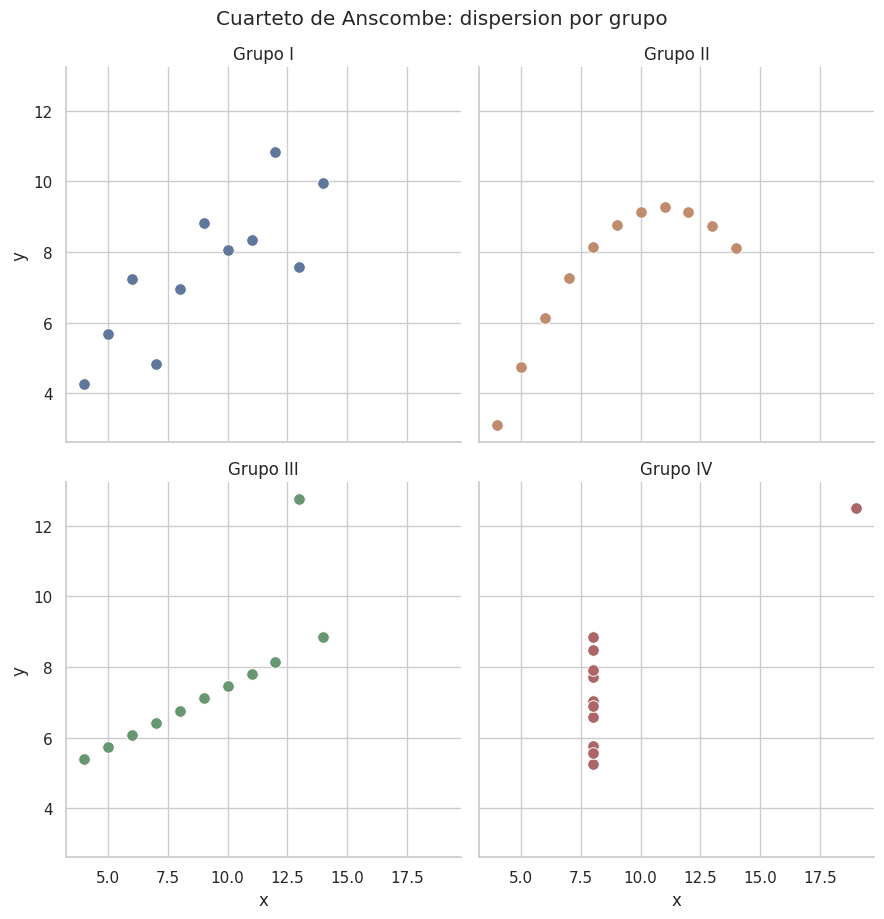

In [ ]:
g = sns.FacetGrid(data, col="dataset", hue="dataset", col_wrap=2, height=4.5)
g.map(sns.scatterplot, "x", "y", s=70)
g.set_titles("Grupo {col_name}")
g.fig.suptitle("Cuarteto de Anscombe: dispersion por grupo", y=1.02)
plt.show()

**¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?**

 Si, a pesar de que los cuatro grupos comparten las mismas propiedades estadisticas basicas (media, varianza, correlacion), los graficos de dispersion revelan patrones completamente distintos:

Grupo I: presenta una relacion lineal razonable, con ruido disperso de forma homogenea alrededor de la recta. Es el unico caso donde un modelo lineal es realmente apropiado.
Grupo II: muestra una relacion claramente no lineal (una curva concava), por lo que un ajuste lineal seria enganoso pese a tener buena correlacion lineal.
Grupo III: los puntos siguen una relacion lineal casi perfecta, salvo por un unico outlier que se aleja notoriamente de la tendencia y que "arrastra" el ajuste lineal.
Grupo IV: casi todos los valores de x son identicos (x=8), excepto un punto con x=19 que determina por si solo la pendiente de la recta; sin ese punto no habria variabilidad en x para ajustar ningun modelo.
Esto demuestra que las estadisticas resumen (media, varianza, correlacion) pueden ser identicas aunque la estructura real de los datos sea muy diferente, de ahi la importancia de visualizar siempre los datos antes de modelar.

2.

In [ ]:
summary = data.groupby('dataset')[['x', 'y']].describe()
summary

x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50

Al aplicar describe() por grupo se confirma que las medidas descriptivas basicas son practicamente identicas entre los cuatro grupos:

La media de x es 9.0 y la de y es aproximadamente 7.5 en los cuatro casos.
La desviacion estandar de x es ~3.32 y la de y es ~2.03 en todos los grupos.
Los valores minimos y maximos de x son iguales en I, II y III (4 a 14), mientras que en el grupo IV el minimo y maximo de x son distintos (8 y 19) debido al punto atipico.
Sin embargo, los percentiles (25%, 50%, 75%) de y si muestran diferencias sutiles entre grupos, lo que ya es un primer indicio numerico de que las distribuciones no son identicas, aunque estas diferencias son mucho menos evidentes que lo que revela la visualizacion grafica. Esto refuerza la leccion central del cuarteto: los estadisticos descriptivos por si solos pueden ocultar diferencias estructurales importantes en los datos.

3.

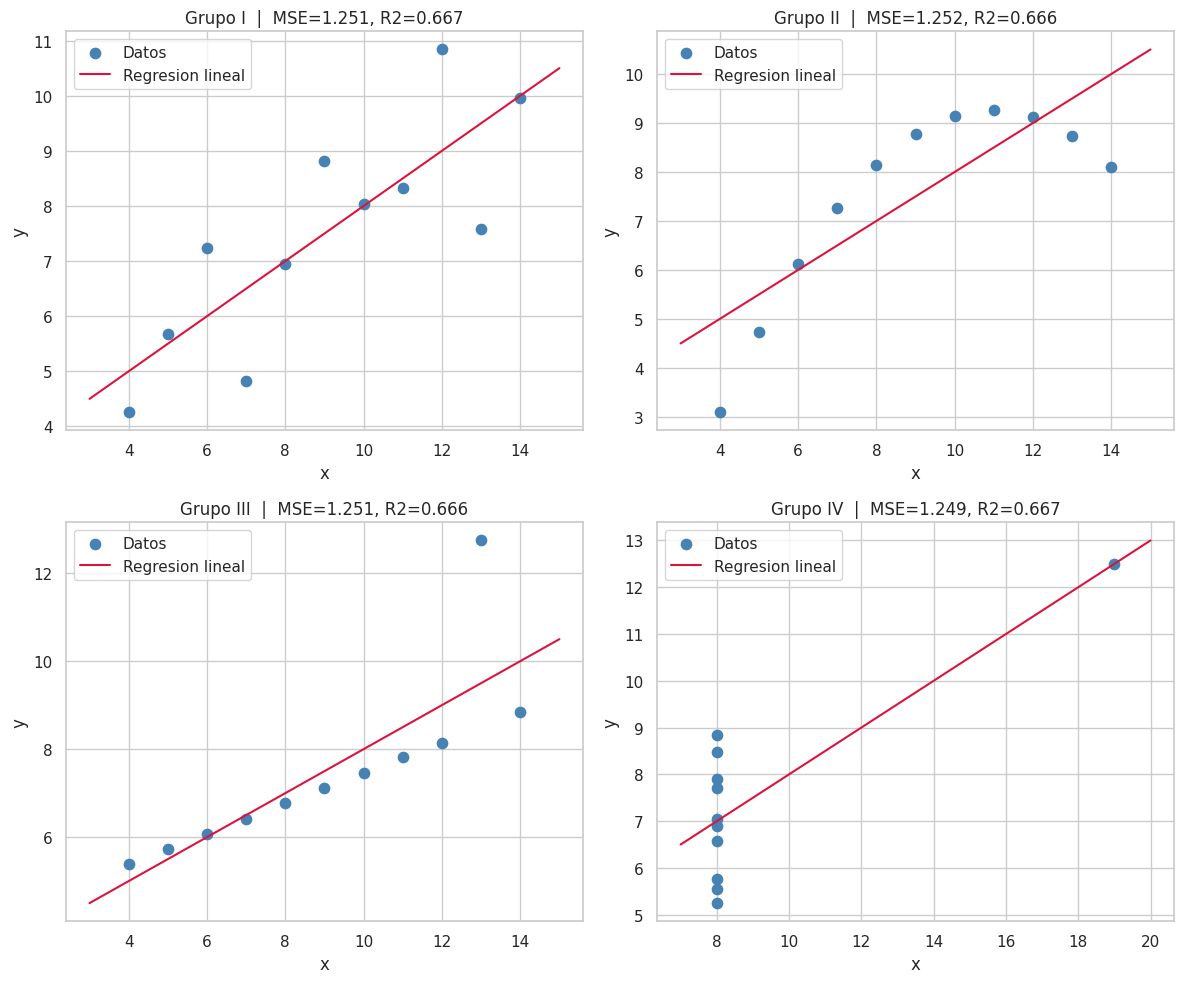

,pendiente,intercepto,mse,r2
I,0.500091,3.000091,1.251154,0.666542
II,0.500000,3.000909,1.252390,0.666242
III,0.499727,3.002455,1.250563,0.666324
IV,0.499909,3.001727,1.249317,0.666707


In [ ]:
results = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, group) in zip(axes, data.groupby('dataset')):
    X = group[['x']].values
    y = group['y'].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    results[name] = {
        'pendiente': model.coef_[0],
        'intercepto': model.intercept_,
        'mse': mse,
        'r2': r2
    }

    x_line = np.linspace(X.min() - 1, X.max() + 1, 100).reshape(-1, 1)
    ax.scatter(X, y, color='steelblue', s=55, label='Datos')
    ax.plot(x_line, model.predict(x_line), color='crimson', label='Regresion lineal')
    ax.set_title(f'Grupo {name}  |  MSE={mse:.3f}, R2={r2:.3f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).T
results_df

Al ajustar una regresion lineal simple (LinearRegression) para cada grupo, se obtiene que los cuatro modelos tienen practicamente la misma pendiente (0.50), el mismo intercepto (3.00), el mismo MSE (1.25) y el mismo R2 (0.67). Esto es justamente el punto central del cuarteto de Anscombe: la calidad numerica del ajuste (medida por MSE y R2) es identica en los cuatro casos, pero al observar los graficos resulta evidente que el modelo lineal:

Es adecuado para el grupo I.
Es inadecuado para el grupo II, ya que la relacion real es curva, no lineal.
Es fuertemente distorsionado por un outlier en el grupo III, que sesga la pendiente aunque el resto de los puntos siga una relacion casi perfecta.
Depende completamente de un unico punto influyente en el grupo IV, que es quien le da toda la variabilidad a la variable x.
Esto confirma que las metricas de error por si solas no bastan para validar un modelo: siempre es necesario revisar los residuos y las visualizaciones para detectar problemas de ajuste.

4.

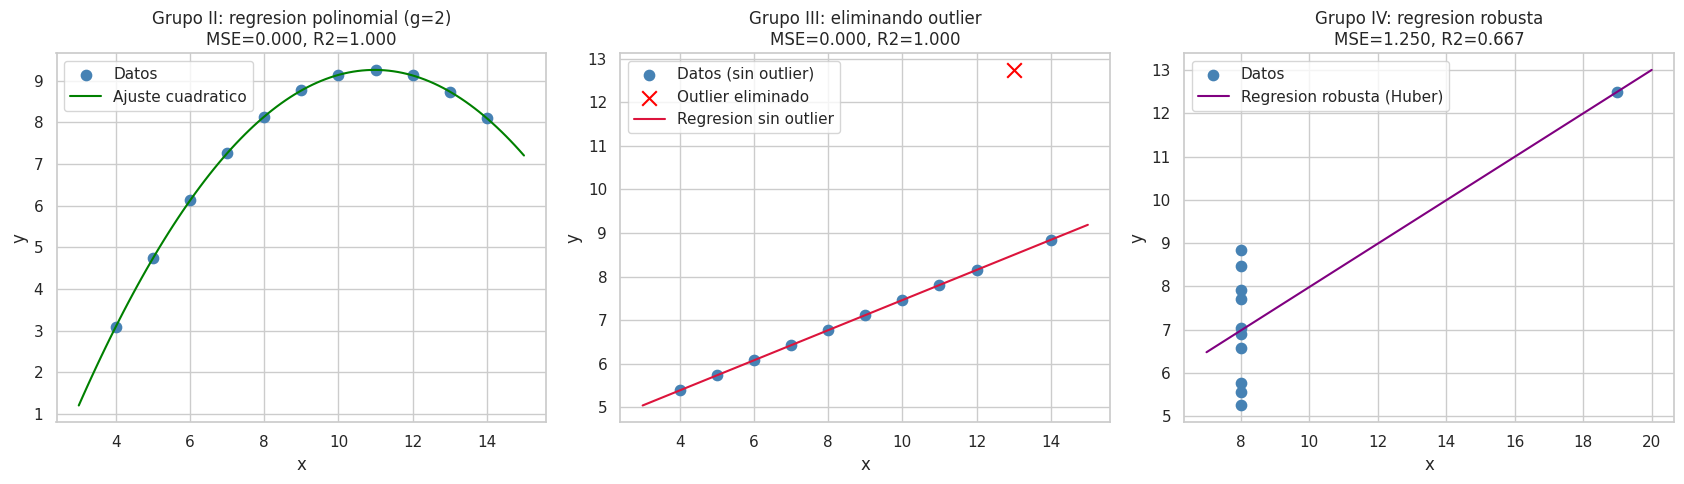

In [13]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import HuberRegressor

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Grupo II: relacion no lineal -> regresion polinomial de grado 2 ---
g2 = data[data['dataset'] == 'II']
X2 = g2[['x']].values
y2 = g2['y'].values

poly = PolynomialFeatures(degree=2)
X2_poly = poly.fit_transform(X2)
model2 = LinearRegression().fit(X2_poly, y2)
y2_pred = model2.predict(X2_poly)
mse2 = mean_squared_error(y2, y2_pred)
r2_2 = r2_score(y2, y2_pred)

x_line = np.linspace(X2.min() - 1, X2.max() + 1, 100).reshape(-1, 1)
axes[0].scatter(X2, y2, color='steelblue', s=55, label='Datos')
axes[0].plot(x_line, model2.predict(poly.transform(x_line)), color='green', label='Ajuste cuadratico')
axes[0].set_title(f'Grupo II: regresion polinomial (g=2)\nMSE={mse2:.3f}, R2={r2_2:.3f}')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].legend()

# --- Grupo III: outlier evidente -> eliminarlo y reajustar el modelo lineal ---
g3 = data[data['dataset'] == 'III'].copy()
X3 = g3[['x']].values
y3 = g3['y'].values

model3_full = LinearRegression().fit(X3, y3)
residuos = y3 - model3_full.predict(X3)
outlier_idx = np.argmax(np.abs(residuos))
mask = np.ones(len(y3), dtype=bool)
mask[outlier_idx] = False

model3_clean = LinearRegression().fit(X3[mask], y3[mask])
y3_pred_clean = model3_clean.predict(X3[mask])
mse3 = mean_squared_error(y3[mask], y3_pred_clean)
r2_3 = r2_score(y3[mask], y3_pred_clean)

x_line = np.linspace(X3.min() - 1, X3.max() + 1, 100).reshape(-1, 1)
axes[1].scatter(X3[mask], y3[mask], color='steelblue', s=55, label='Datos (sin outlier)')
axes[1].scatter(X3[~mask], y3[~mask], color='red', marker='x', s=110, label='Outlier eliminado')
axes[1].plot(x_line, model3_clean.predict(x_line), color='crimson', label='Regresion sin outlier')
axes[1].set_title(f'Grupo III: eliminando outlier\nMSE={mse3:.3f}, R2={r2_3:.3f}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].legend()

# --- Grupo IV: punto de alto apalancamiento -> regresion robusta (Huber) ---
g4 = data[data['dataset'] == 'IV']
X4 = g4[['x']].values
y4 = g4['y'].values

huber = HuberRegressor().fit(X4, y4)
y4_pred = huber.predict(X4)
mse4 = mean_squared_error(y4, y4_pred)
r2_4 = r2_score(y4, y4_pred)

x_line = np.linspace(X4.min() - 1, X4.max() + 1, 100).reshape(-1, 1)
axes[2].scatter(X4, y4, color='steelblue', s=55, label='Datos')
axes[2].plot(x_line, huber.predict(x_line), color='purple', label='Regresion robusta (Huber)')
axes[2].set_title(f'Grupo IV: regresion robusta\nMSE={mse4:.3f}, R2={r2_4:.3f}')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y'); axes[2].legend()

plt.tight_layout()
plt.show()

Cada grupo problematico requiere una estrategia distinta, ya que el problema de fondo no es el mismo en cada caso:

Grupo II (relacion no lineal): se ajusto una regresion polinomial de grado 2 en lugar de una recta. El resultado captura mucho mejor la curvatura de los datos, mejorando notoriamente el R2 respecto al modelo lineal original.
Grupo III (outlier puntual): se identifico el punto con mayor residuo respecto a la recta original y se elimino antes de reajustar el modelo lineal. Sin el outlier, el ajuste lineal vuelve a ser practicamente perfecto (R2 muy cercano a 1), confirmando que un unico dato atipico era el responsable de distorsionar el modelo.
Grupo IV (punto de alto apalancamiento): en este caso eliminar el punto no es una opcion razonable, porque es el unico que aporta variabilidad a x (sin el, no se podria ajustar ninguna recta). En su lugar se uso una regresion robusta (HuberRegressor), que reduce la influencia de valores atipicos sin descartarlos, logrando una estimacion mas estable de la relacion entre x e y.
En resumen: no existe una unica solucion universal frente a un mal ajuste lineal. La estrategia correcta depende de si el problema es la forma de la relacion (grupo II), la presencia de un dato espurio (grupo III), o la falta de variabilidad real en los datos salvo por un punto influyente (grupo IV). En todos los casos, la visualizacion fue clave para diagnosticar el problema antes de elegir la solucion.